In [1]:
%load_ext autoreload
%autoreload 2
%config IPCompleter.greedy = True

# pyEPR Startup Example
##### Single transmon qubit mode analysis
Author: Zlatko Minev

## Introduction: The Energy-Participation Ratio (EPR) Method

The **energy-participation ratio (EPR) method** is a quantum circuit design framework that provides a rigorous and efficient bridge between a classical electromagnetic (EM) simulation and the quantum Hamiltonian of a superconducting circuit. Rather than deriving circuit parameters by hand from a schematic, the EPR method extracts them directly from the full-wave, distributed electromagnetic field solutions computed by a finite-element solver such as Ansys HFSS.

The method is described in detail in:

> Z. K. Minev, Z. Leghtas, S. O. Mundhada, L. Christakis, I. M. Pop, and M. H. Devoret,  
> **"Energy-participation quantization of Josephson circuits"**,  
> *npj Quantum Information* **7**, 131 (2021).  
> Preprint: [arXiv:2010.00620](https://arxiv.org/abs/2010.00620)

This tutorial walks through the complete analysis pipeline for a single transmon qubit coupled to a 3D microwave cavity. By the end you will have extracted the qubit frequency, anharmonicity, and dispersive coupling from an HFSS eigenmode simulation.

---

### The three-stage EPR pipeline

**Stage 1 — Classical eigenmode simulation (HFSS)**

The circuit is simulated in the *linearized* regime, meaning the Josephson junction (JJ) is replaced by its linear inductance $L_J$. HFSS solves Maxwell's equations to find the electromagnetic eigenmodes: resonant frequencies $\omega_m / 2\pi$ and the associated spatial field distributions $\mathbf{E}_m(\mathbf{r}),\, \mathbf{H}_m(\mathbf{r})$.

**Stage 2 — EPR extraction (DistributedAnalysis)**

For each mode $m$ and each Josephson junction $j$, pyEPR computes the **energy-participation ratio**:
$$p_{mj} = \frac{\omega_m}{E_J} \frac{\partial E_J}{\partial (1/L_j)} \cdot \frac{1}{2} = \frac{\text{inductive energy in junction } j \text{ for mode } m}{\text{total inductive energy of mode } m}$$

In practice $p_{mj}$ is computed from the zero-point voltage across the junction using a line integral of the electric field along the polyline that spans the junction rectangle:
$$p_{mj} = \frac{\omega_m L_j}{\hbar \omega_m / (2 e^2)} \cdot \frac{V_{zpf,j}^2}{2 \omega_m}
       \;\approx\; \frac{L_j \left|\int_{\ell_j} \mathbf{E}_m \cdot d\mathbf{\ell}\right|^2}{4 \omega_m^2 \mathcal{E}_m^{(E)}}$$
where $\mathcal{E}_m^{(E)}$ is the peak electric energy of mode $m$. See Eq. (4) and Appendix B of [arXiv:2010.00620](https://arxiv.org/abs/2010.00620) for the precise definition.

The **zero-point flux fluctuation** across junction $j$ in mode $m$ is:
$$\varphi_{zpf}^{(mj)} = \sqrt{\frac{p_{mj}\, \hbar \omega_m}{2 E_J}}$$
This dimensionless quantity quantifies how strongly each mode couples to the nonlinearity of the junction.

**Stage 3 — Quantum Hamiltonian analysis (QuantumAnalysis)**

The EPR method maps the system to the quantum Hamiltonian (see Eq. (1) of the paper):
$$\hat{H} = \sum_m \hbar\omega_m \hat{a}_m^\dagger \hat{a}_m - \sum_j E_J \left[\cos\left(\sum_m \varphi_{zpf}^{(mj)}(\hat{a}_m + \hat{a}_m^\dagger)\right) - 1 + \frac{\varphi_j^2}{2}\right]$$
Numerical diagonalization (or perturbation theory) of this Hamiltonian yields:
- **Dressed mode frequencies** $\tilde{\omega}_m$ (shifted from $\omega_m$ by the Lamb shift due to junction nonlinearity)
- **Anharmonicities** $\alpha_m = \chi_{mm}$ (diagonal of the $\chi$ matrix)
- **Dispersive couplings** $\chi_{mn}$ (off-diagonal; quantifies qubit-cavity interaction strength)

---

### The three main pyEPR classes

| Class | Role |
|---|---|
| `ProjectInfo` | Configuration: HFSS project path, junction definitions, solver settings |
| `DistributedAnalysis` | Runs field extraction in HFSS; computes EPRs (Stage 1 & 2) |
| `QuantumAnalysis` | Loads EPR results; diagonalizes quantum Hamiltonian (Stage 3) |

Let us now work through each stage step by step.

## <div style="background:#BBFABB;line-height:2em;">Load pyEPR<div>

In [2]:
import pyEPR_pyaedt as epr

This loads the `pyEPR` package under the shorthand name `epr`.

We can access the main submodules as follows:

* `epr.calcs`   : calculation tools (EPR math, unit conversion, Josephson energy formulas)
* `epr.ansys`   : tools for controlling Ansys HFSS, Q3D, etc. via COM
* `epr.toolbox` : useful toolbox for plotting, pandas helpers, and Python utilities
* `epr.core`    : the core analysis classes — `ProjectInfo`, `DistributedAnalysis`, and `QuantumAnalysis`

pyEPR also exposes several convenient utility functions at the top level. For example, `parse_entry` converts human-readable length strings to SI units, and the `calcs.Convert` submodule handles physical constant conversions such as Josephson energy from junction inductance:

In [3]:
print('Parsing unis:  1um =',
      epr.parse_entry('1um', 'meters'), 'meters')

print(f"""For   L_J = 11 nH, the Josephson junction energy is
      E_J = {epr.calcs.Convert.Ej_from_Lj(11, 'nH', 'GHz'):.1f} GHz""")

Parsing unis:  1um = 1e-06 meters
For   L_J = 11 nH, the Josephson junction energy is
      E_J = 14.9 GHz


The Josephson energy $E_J$ is related to the junction inductance $L_J$ through the Josephson relation:
$$E_J = \frac{\Phi_0^2}{(2\pi)^2 L_J} = \frac{\hbar^2}{4 e^2 L_J}$$
where $\Phi_0 = h / (2e)$ is the magnetic flux quantum. For a typical transmon with $L_J \approx 11\,\text{nH}$, this gives $E_J / h \approx 15\,\text{GHz}$. The transmon qubit frequency is approximately $\omega_q \approx \sqrt{8 E_J E_C} - E_C$ (where $E_C$ is the charging energy), so knowing $E_J$ is essential for device design.

#### Load Ansys HFSS tutorial file

Let us first determine where the example file is stored. The tutorial HFSS project ships with the pyEPR repository under `_example_files/`. We use `pathlib.Path` to construct the path relative to the installed package location.

In [4]:
# Load Path temporarily just to find where the tutorial folder is
# return path_to_project
from pathlib import Path
path_to_project = Path(epr.__file__).parent.parent / '_example_files'
print(f'We will the example project located in\n {path_to_project}')

We will the example project located in
 C:\Code\pyEPR_pyaedt\_example_files


## <div style="background:#BBFABB;line-height:2em;">Connect to Ansys HFSS<div>

Now, we will open Ansys Desktop and connect to a specific project.

`ProjectInfo` is the first of the three main pyEPR classes. It manages the connection to Ansys HFSS and stores all the configuration needed for the analysis — including junction definitions, dissipative element lists, and solver settings.

You can use the following creation keyword arguments to specify which design to look at:

* `project_path`: Directory path to the HFSS project file. Should be the directory, not the file itself. `None` assumes the project is already open and gets the project based on `project_name`.
* `project_name`: Name of the project within `project_path`. `None` will get the current active one.
* `design_name`:  Name of the design within the project. `None` will get the current active one.
* `setup_name`:   Name of the setup within the design. `None` will get the current active one.

Use `?epr.ProjectInfo` to see all arguments.

In [5]:
pinfo = epr.ProjectInfo(project_path = path_to_project,
                         project_name = 'pyEPR_tutorial1',
                         design_name  = '1. single_transmon')

INFO 12:46PM [connect_project]: Connecting to Ansys Desktop API...


INFO 12:46PM [load_ansys_project]: 	File path to HFSS project found.


INFO 12:46PM [connect_desktop]: Connecting to AEDT via PyAEDT (version=None, new_desktop=False, non_graphical=False)...


PyAEDT INFO: Python version 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)].


PyAEDT INFO: PyAEDT version 0.26.1.


...

INFO 12:46PM [load_ansys_project]: 	Opened Ansys Desktop v2025.2


INFO 12:46PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Code/pyEPR_pyaedt/_example_files/
	Project:   pyEPR_tutorial1


INFO 12:46PM [connect_design]: 	Opened active design
	Design:    1. single_transmon [Solution type: Eigenmode]


INFO 12:46PM [get_setup]: 	Opened setup `Setup1`  (<class 'pyEPR_pyaedt.ansys.HfssEMSetup'>)


INFO 12:46PM [connect]: 	Connected to project "pyEPR_tutorial1" and design "1. single_transmon" 😀 



Let's see what the design type was using the `design` object. For the EPR analysis we always use an **Eigenmode** solution type, which finds the resonant frequencies and field distributions of the linearized circuit.

In [6]:
pinfo.design.solution_type

'Eigenmode'

Let us see what all the objects in the design are. `pinfo` contains a convenience function to retrieve these. In the tutorial design you will find:

- `cavity_enclosure`: the 3D metallic box forming the microwave cavity
- `substrate`: the silicon or sapphire chip on which the qubit is fabricated
- `rect_jj1`: the rectangle sheet that defines the Josephson junction lumped boundary
- `pad_lower`, `pad_upper`: the capacitor pads of the transmon qubit
- `line_jj1`: the polyline spanning the junction rectangle (defines current direction)

In [7]:
pinfo.get_all_object_names()

['cavity_enclosure',
 'substrate',
 'rect_jj1',
 'pad_lower',
 'pad_upper',
 'line_jj1']

Let's see what design variables are available. HFSS design variables parametrize the geometry and material properties of the model. The variable `Lj_1` is of particular importance — it is the Josephson inductance that pyEPR will read from HFSS to compute the EPR.

In [8]:
pinfo.get_all_variables_names()

['width',
 'height',
 'length',
 'c_w',
 'c_h',
 'c_l',
 'pad_gap',
 'jj_w',
 'pad_w',
 'pad_h',
 'Lj_1']

We can also get the names of the setups.

In [9]:
pinfo.design.get_setup_names()

['Setup1']

We can also retrieve information such as mesh statistics and convergence (if the model has already been solved). The mesh quality determines the accuracy of the field integrals used in the EPR calculation. A well-converged eigenmode solution typically requires $\Delta f / f < 0.5\%$ between successive adaptive passes.

In [10]:
pinfo.setup.get_mesh_stats()

,Unnamed: 0,Num Tets,Min edge length,Max edge length,RMS edge length,Min tet vol,Max tet vol,Mean tet vol,Std Devn (vol)
0,cavity_enclosure,231982,0.008717,3.26412,0.666273,4.214620e-08,1.083430,0.016499,0.023642
1,substrate,16065,0.010174,1.45000,0.219689,5.181550e-08,0.048333,0.000505,0.001001


We can also see how many modes we solved for.

In [11]:
pinfo.setup.n_modes

'2'

##  <div style="background:#BBFABB;line-height:2em;"> Josephson Tunnel Junctions (Non-Linear Elements) </div>

### Physics of the Josephson junction in HFSS

In an HFSS eigenmode simulation the Josephson junction is modeled as a **lumped RLC boundary condition** — a rectangular sheet with a specified sheet inductance $L_J$. This is the correct linearized representation because, for small oscillations around the superconducting phase minimum, the JJ potential energy $-E_J \cos(\varphi) \approx E_J \varphi^2 / 2 - E_J \varphi^4 / 24 + \ldots$ is dominated by the harmonic (quadratic) term, which corresponds exactly to an inductor with inductance:
$$L_J = \frac{\Phi_0^2}{(2\pi)^2 E_J} = \frac{\hbar^2}{4 e^2 E_J}$$

The **anharmonicity** — the deviation from a perfect harmonic oscillator that makes the qubit addressable — comes from the quartic and higher-order terms in the cosine expansion. The EPR method captures these nonlinear corrections in Stage 3 (quantum Hamiltonian analysis), after extracting the linear mode structure in Stages 1 and 2.

Each junction in the model is described by four pieces of information:

1. **`Lj_variable`**: the name of the HFSS design variable that specifies $L_J$ on the lumped boundary condition. pyEPR reads this variable to compute $E_J = \Phi_0^2 / (4\pi^2 L_J)$.
2. **`rect`**: the name of the HFSS rectangle on which the lumped boundary condition is applied. The **area** of this rectangle determines the current density normalization.
3. **`line`**: the name of the HFSS polyline that spans the length of the rectangle, parallel to the current flow direction. The zero-point voltage is computed by integrating the electric field $\mathbf{E}$ along this line.
4. **`length`**: the physical length of the junction (used for normalization in the EPR line-voltage calculation).

An optional `Cj_variable` can be specified if a lumped capacitance is placed in parallel with the junction in the HFSS model.

To analyze the quantum part of the model, let us now register the junctions present in the design. We call the single junction `j1`:

In [12]:
pinfo.junctions['j1'] = {'Lj_variable' : 'Lj_1',
                         'rect'        : 'rect_jj1',
                         'line'        : 'line_jj1',
                         'length'      : epr.parse_units('100um')}


# Check that valid names of variables and objects have been supplied.
# An error is raised with a message if something is wrong.
pinfo.validate_junction_info()

## <div style="background:#BBFABB;line-height:2em;">Microwave Analysis:<br>Run analysis on an eigenmode solution  <div>

Assuming we have field solutions saved for the HFSS *eigenmode* design, we can now create the analysis object from the class `DistributedAnalysis`.

**Run analysis (tutorial action):** Run the analysis in the design model. This can be done manually in the HFSS GUI, or programmatically using pyEPR.

In [13]:
# Calling this function will run an analysis of the design in the background.
# The console will wait for HFSS to complete.
pinfo.setup.analyze()

INFO 12:46PM [analyze]: Analyzing setup Setup1


0

**Run optimetrics**

If an optimetrics (parametric sweep) setup is defined in HFSS, the following call will execute it. Each parametric point generates a separate set of field solutions that pyEPR can subsequently analyze.

The following will get the frequencies and Qs from HFSS.

In [14]:
# Calling this function will run an analysis on all the optimetrics  the design in the background.
# The console will wait for HFSS to complete.
# This requires optimetrics license by HFSS.
pinfo.design.optimetrics.solve_setup(pinfo.design.optimetrics.get_setup_names()[0])

**EPR Analysis object**

Let us introduce the core analysis object of `pyEPR`, which will be a class instance of `epr.DistributedAnalysis`. This is the classical-to-quantum bridge: it connects to HFSS, retrieves the electromagnetic field solutions, and computes the energy-participation ratios for each mode and junction.

Let us recover the eigenmode frequencies of the first variation we ran, which is indexed by `'0'`.

In [15]:
# This is the core object for interacting with HFSS
# and running analysis within HFSS.
eprh = epr.DistributedAnalysis(pinfo) # epr hfss analysis

INFO 12:47PM [__init__]: Design "1. single_transmon" info:


INFO 12:47PM [__init__]: 	# eigenmodes    2
	# variations    11


In [16]:
eprh.get_ansys_variables()

variation,0,1,2,3,4,5,6,7,8,9,10
c_h,0.40000000000000002mm,0.40000000000000002mm,0.40000000000000002mm,0.40000000000000002mm,0.40000000000000002mm,0.40000000000000002mm,0.40000000000000002mm,0.40000000000000002mm,0.40000000000000002mm,0.40000000000000002mm,0.40000000000000002mm
c_l,7mm,7mm,7mm,7mm,7mm,7mm,7mm,7mm,7mm,7mm,7mm
c_w,2.8999999999999999mm,2.8999999999999999mm,2.8999999999999999mm,2.8999999999999999mm,2.8999999999999999mm,2.8999999999999999mm,2.8999999999999999mm,2.8999999999999999mm,2.8999999999999999mm,2.8999999999999999mm,2.8999999999999999mm
height,17mm,17mm,17mm,17mm,17mm,17mm,17mm,17mm,17mm,17mm,17mm
jj_w,50um,50um,50um,50um,50um,50um,50um,50um,50um,50um,50um
length,33mm,33mm,33mm,33mm,33mm,33mm,33mm,33mm,33mm,33mm,33mm
Lj_1,12nH,7nH,8nH,9nH,10nH,11nH,6nH,7.2000000000000002nH,8.4000000000000004nH,9.5999999999999996nH,10.800000000000001nH
pad_gap,100um,100um,100um,100um,100um,100um,100um,100um,100um,100um,100um
pad_h,350um,350um,350um,350um,350um,350um,350um,350um,350um,350um,350um
pad_w,0.75mm,0.75mm,0.75mm,0.75mm,0.75mm,0.75mm,0.75mm,0.75mm,0.75mm,0.75mm,0.75mm


In [17]:
eprh.get_ansys_frequencies_all()

Freq. (GHz)  Quality Factor
variation mode                             
0         0        4.203269             inf
          1        9.236999             inf
1         0        5.419393             inf
          1        9.247233             inf
2         0        5.079924             inf
          1        9.243341             inf
3         0        4.796979             inf
          1        9.240603             inf
4         0        4.556488             inf
          1        9.238573             inf
5         0        4.348820             inf
          1        9.237008             inf
6         0        5.848828             inf
          1        9.253026             inf
7         0        5.522325             inf
          1        9.250541             inf
8         0        5.083237             inf
          1        9.245096             inf
9         0        4.853884             inf
          1        9.244825             inf
10        0        4.581920             inf
          1        9.242459             inf

INFO 12:47PM [hfss_report_full_convergence]: Creating report for variation 0


INFO 12:47PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


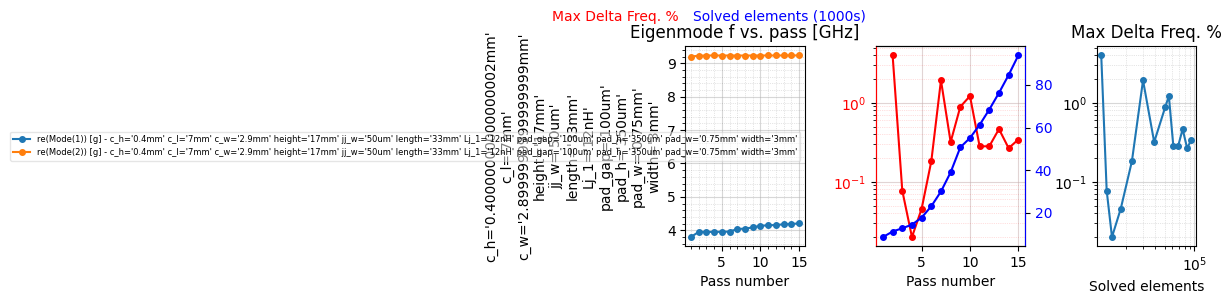

INFO 12:47PM [hfss_report_full_convergence]: Creating report for variation 1


INFO 12:47PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


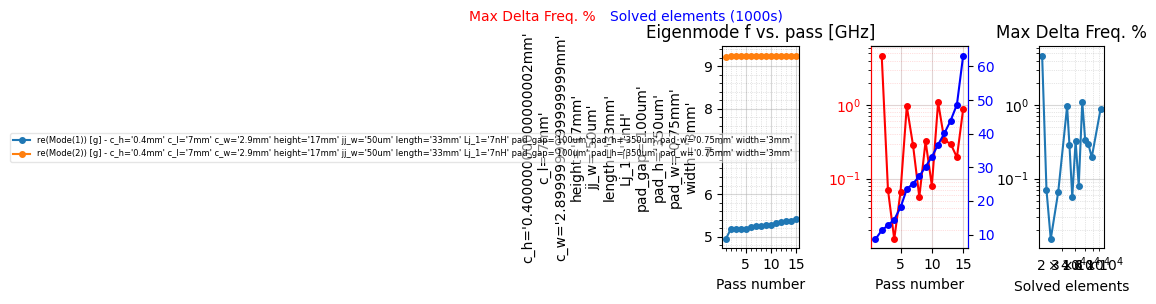

INFO 12:47PM [hfss_report_full_convergence]: Creating report for variation 2


INFO 12:47PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


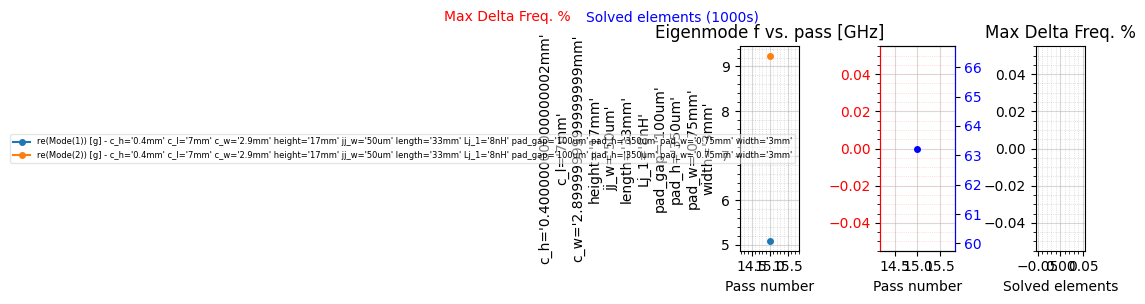

INFO 12:47PM [hfss_report_full_convergence]: Creating report for variation 3


INFO 12:47PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


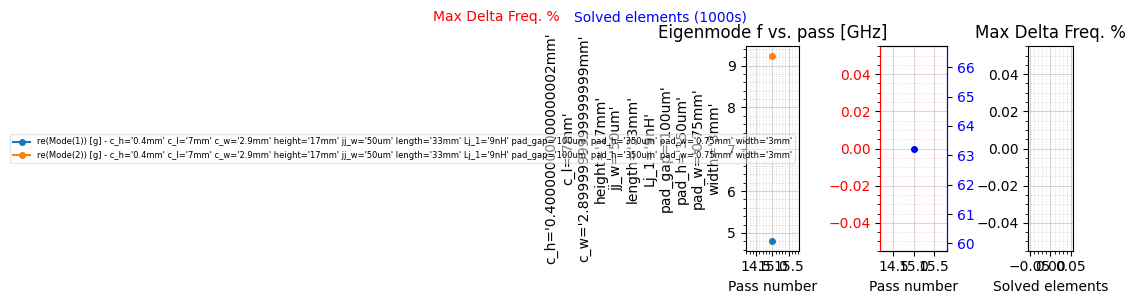

INFO 12:47PM [hfss_report_full_convergence]: Creating report for variation 4


INFO 12:47PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


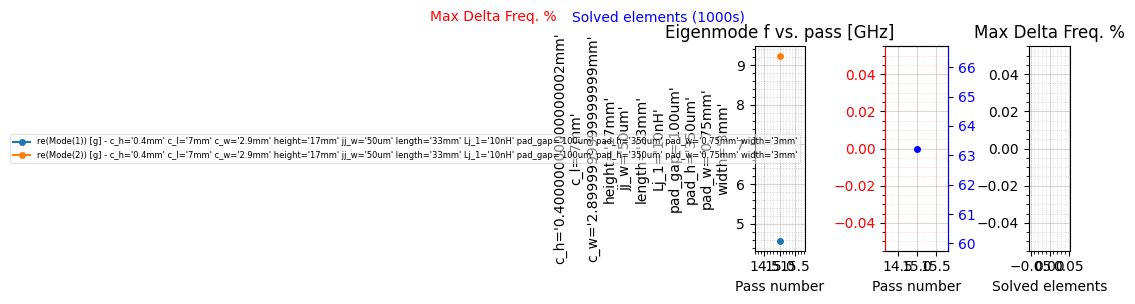

INFO 12:47PM [hfss_report_full_convergence]: Creating report for variation 5


INFO 12:47PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


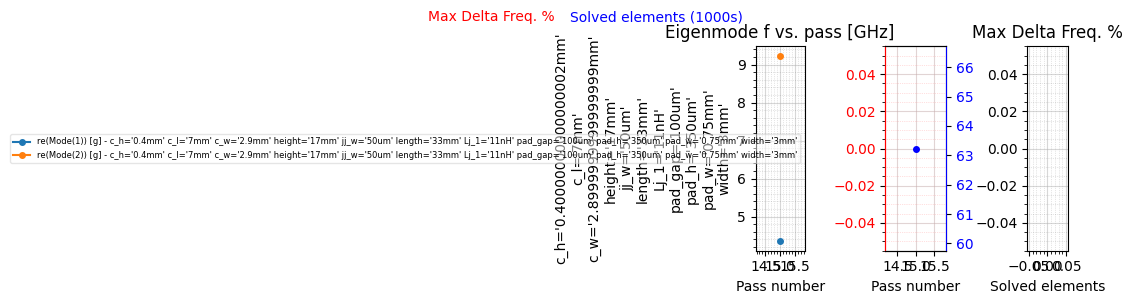

INFO 12:47PM [hfss_report_full_convergence]: Creating report for variation 6


INFO 12:47PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


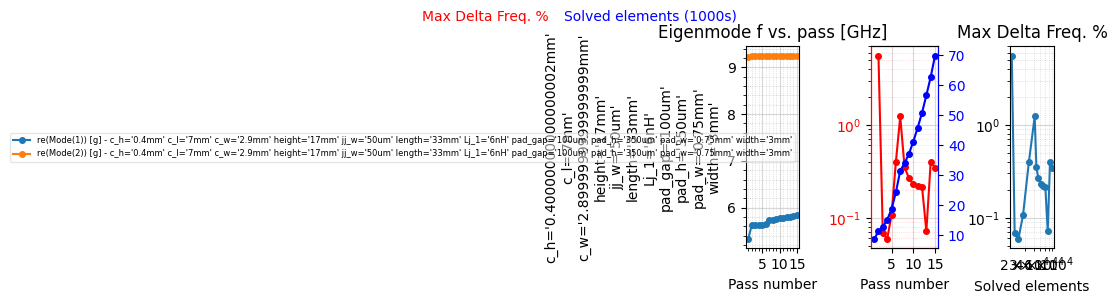

INFO 12:47PM [hfss_report_full_convergence]: Creating report for variation 7


INFO 12:47PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


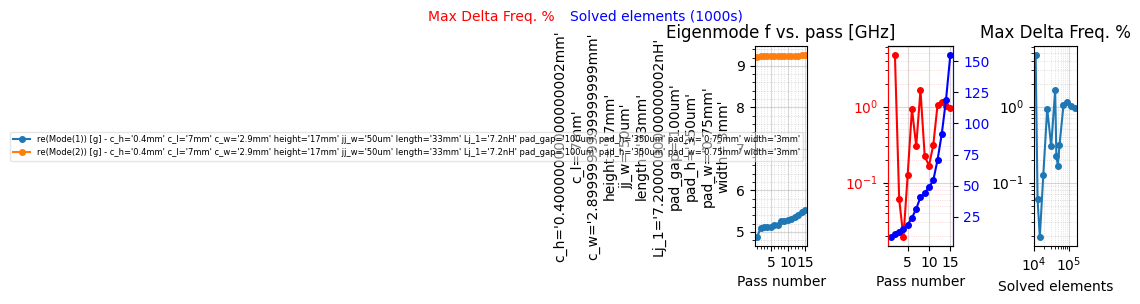

INFO 12:47PM [hfss_report_full_convergence]: Creating report for variation 8


INFO 12:47PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


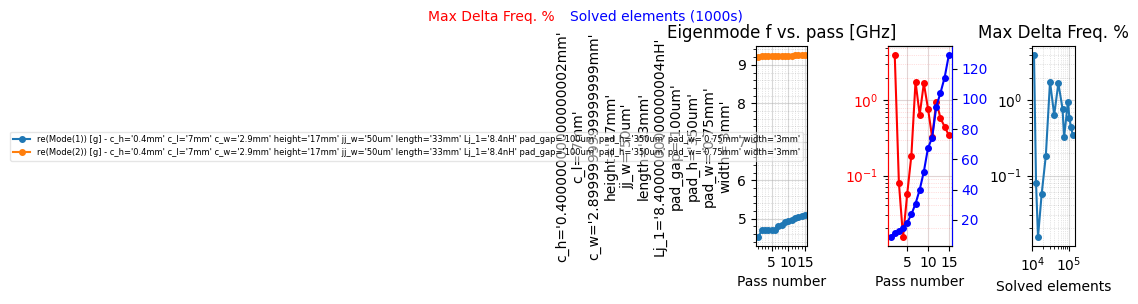

INFO 12:47PM [hfss_report_full_convergence]: Creating report for variation 9


INFO 12:47PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


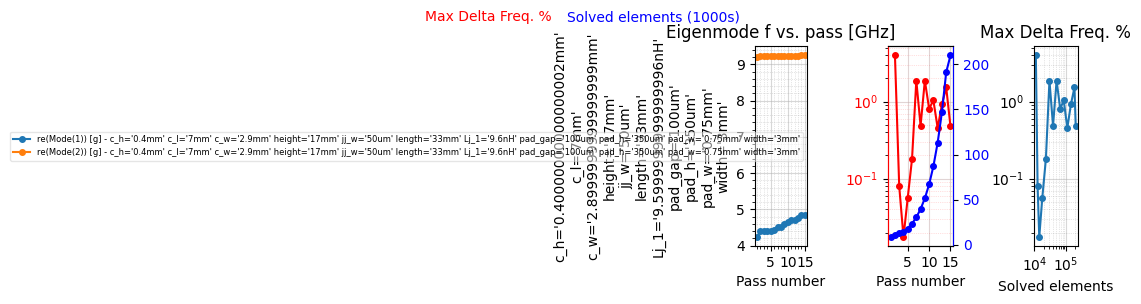

INFO 12:47PM [hfss_report_full_convergence]: Creating report for variation 10


INFO 12:47PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


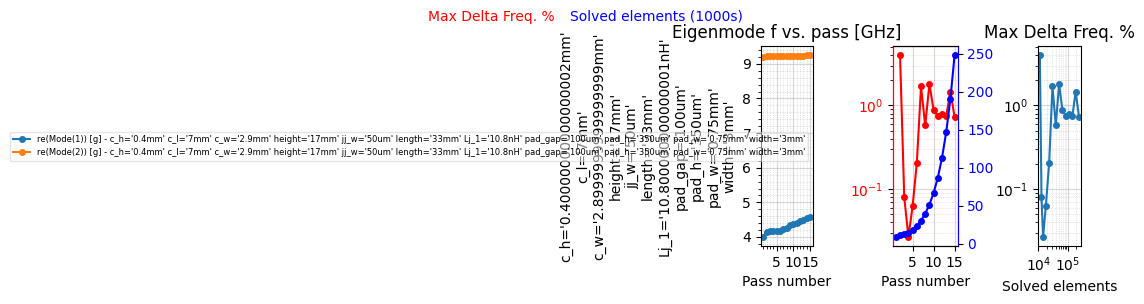

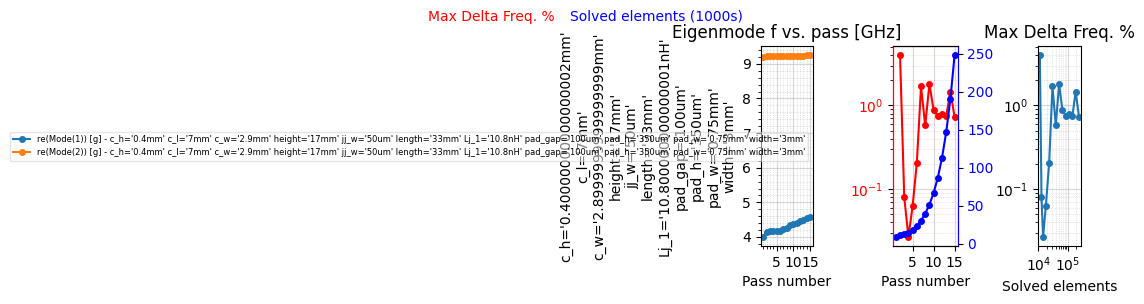

In [18]:
eprh.hfss_report_full_convergence();

We can see that the convergence is reasonable for this tutorial example. In production designs, one typically targets $\Delta f / f < 0.1\%$ between adaptive mesh passes and a monotonically decreasing convergence curve. Mesh refinement operations (e.g., seeding finer elements around the junction rectangle or the qubit capacitor pads) can improve convergence.

For this tutorial, let us press forward.

You can use these autogenerated reports to keep track of your simulations. This is still all at the classical level. Take a look at the other available methods:

* `hfss_report_full_convergence`
* `hfss_report_f_convergence`
* `get_convergence`
* `get_mesh_statistics`
* `get_freqs_bare_pd`
* ...

For example, you can get tables of the frequencies and Q factors using:
```python
Fs, Qs = eprh.get_freqs_bare_pd(variation='0')
```

In [19]:
import pandas as pd
for variation in eprh.variations[:2]: # just for the first 2
    Fs, Qs = eprh.get_freqs_bare_pd(variation=variation, frame=False)
    display(pd.DataFrame({'Freq. (GHz)':Fs, 'Quality Factor':Qs}))

,Freq. (GHz),Quality Factor
0,4.203269,inf
1,9.236999,inf


,Freq. (GHz),Quality Factor
0,5.419393,inf
1,9.247233,inf


The Q is infinite, since we have not included dissipation in this example — there are no lossy boundaries or bulk dielectrics defined in the HFSS model. The row index is the mode number:
- **Mode 0** (~5 GHz): the transmon qubit mode
- **Mode 1** (~9 GHz): the cavity mode

Dissipation can be modeled by specifying the corresponding HFSS objects for bulk dielectrics, surface losses, resistive surfaces, or seams when initializing `ProjectInfo`. For example:
```python
pinfo = epr.ProjectInfo(project_path = path_to_project, 
                        project_name = 'pyEPR_tutorial1',
                        design_name  = '1. single_transmon',
                        dielectrics_bulk = ['si_substrate'],
                        dielectric_surfaces = ['interface'],
                        resistive_surfaces = None,
                        seams = None)
```
or equivalently, after the fact:
```python
pinfo.dissipative['dielectrics_bulk'] = ['si_substrate']
pinfo.dissipative['dielectric_surfaces'] = ['interface']
```
See Tutorial 2 for a detailed treatment of dielectric loss calculation.

####  Full EPR Analysis

### What does `do_EPR_analysis` compute?

This is the heart of the pyEPR workflow — the classical-to-quantum bridge. For each eigenmode and each parametric variation (e.g., each value of $L_J$ in a sweep), `do_EPR_analysis` performs the following steps:

1. **Field retrieval**: Queries HFSS for the electric and magnetic field distributions $\mathbf{E}_m(\mathbf{r})$, $\mathbf{H}_m(\mathbf{r})$ of mode $m$.

2. **Energy balance check**: Computes the total electric energy $\mathcal{E}_m^{(E)}$ and magnetic energy $\mathcal{E}_m^{(H)}$ by volume integration over the entire simulation domain:
   $$\mathcal{E}_m^{(E)} = \frac{1}{4}\mathrm{Re}\int_V dv\, \mathbf{E}_m^* \cdot \overleftrightarrow{\epsilon} \cdot \mathbf{E}_m$$
   For a well-converged eigenmode, $\mathcal{E}_m^{(E)} \approx \mathcal{E}_m^{(H)}$ (energy equipartition). A large imbalance signals poor mesh convergence.

3. **Junction EPR calculation**: For each junction $j$, computes the participation ratio $p_{mj}$ by integrating the electric field along the polyline $\ell_j$:
   $$p_{mj} = \frac{\omega_m L_j \left| \int_{\ell_j} \mathbf{E}_m \cdot d\mathbf{\ell} \right|^2}{4 \omega_m^2 \mathcal{E}_m^{(E)}}$$
   See Eq. (4) and Appendix B of [arXiv:2010.00620](https://arxiv.org/abs/2010.00620).

4. **Sign determination**: Computes the sign $s_{mj} = \pm 1$ of the zero-point flux fluctuation, which determines whether modes are hybridized constructively or destructively at the junction.

5. **Data storage**: Saves all results (frequencies, participation matrices, sign matrices, and energy values) to an HDF5 file for subsequent quantum analysis.

The output printed during the run shows, for each mode, the energy balance $(\mathcal{E}_E - \mathcal{E}_H)/\mathcal{E}_E$ and the computed EPR $p_{mj}$ for each junction.

In [20]:
# Do EPR analysis for all modes and all variations
# If you want to only analze a certain variation, you can change the
# default keyword argeumetns variations=None, modes=None
eprh.do_EPR_analysis();

PyAEDT INFO: Python version 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)].


PyAEDT INFO: PyAEDT version 0.26.1.


PyAEDT INFO: Returning found Desktop session with PID 6016!


PyAEDT INFO: Project pyEPR_tutorial1 set to active.


PyAEDT INFO: Active Design set to 1. single_transmon


...

INFO 12:48PM [do_EPR_analysis]:     Calculating junction EPR, method=`line_voltage`


INFO 12:48PM [do_EPR_analysis]: 	junction        EPR p_1j   sign s_1j    (p_capacitive)


INFO 12:48PM [calc_p_junction]: 	j1              0.00346618  (-)        0.000252487


INFO 12:48PM [calc_p_junction]: 		(U_tot_cap-U_tot_ind)/mean=0.01%


INFO 12:48PM [do_EPR_analysis]: ANALYSIS DONE. Data saved to: C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\2026-07-03 12-47-09.npz


##### Getting more info

In general, to see more verbose output when running commands, set the logger level to `DEBUG`.

In [21]:
import logging
epr.logger.setLevel(logging.DEBUG)

## <div style="background:#BBFABB;line-height:2em;"> Quantum Hamiltonian Analysis:<br> Load microwave analysis results and perform Hamiltonian analysis on the solutions  <div>

### The quantum Hamiltonian and its diagonalization

Having computed the EPR participation matrix $p_{mj}$ and zero-point flux fluctuations $\varphi_{zpf}^{(mj)}$ for each mode–junction pair, we can now construct and diagonalize the full quantum Hamiltonian. This is done by the `QuantumAnalysis` class.

The system Hamiltonian (in the basis of the linearized HFSS eigenmodes) is (Eq. (1) of [arXiv:2010.00620](https://arxiv.org/abs/2010.00620)):
$$\hat{H} = \sum_m \hbar\omega_m \hat{a}_m^\dagger \hat{a}_m - \sum_j E_J^{(j)} \left[\cos\!\left(\hat{\varphi}_j\right) - 1 + \frac{\hat{\varphi}_j^2}{2}\right]$$
where the phase operator for junction $j$ is:
$$\hat{\varphi}_j = \sum_m s_{mj}\, \varphi_{zpf}^{(mj)} \left(\hat{a}_m + \hat{a}_m^\dagger\right)$$

The cosine is expanded as a Taylor series (truncated at order `cos_trunc`) and the resulting polynomial in bosonic operators is diagonalized numerically in a truncated Fock space of dimension `fock_trunc` per mode. Two levels of analysis are provided:

- **First-order perturbation theory (PT)**: Analytic result valid when $\varphi_{zpf} \ll 1$ (transmon regime). Fast, but less accurate for strongly anharmonic or hybridized modes.
- **Numerical diagonalization (ND)**: Full numerical diagonalization in the Fock space. More accurate, but computationally more expensive.

**Key parameters:**
- `cos_trunc`: Number of terms in the Taylor expansion of $\cos(\hat{\varphi})$ kept in the Hamiltonian. Typical value: 8. Higher values improve accuracy at the cost of computation time.
- `fock_trunc`: Dimension of the truncated Fock space per mode. Typical value: 15 (i.e., states $|0\rangle, |1\rangle, \ldots, |14\rangle$). Must be large enough that truncation errors are negligible.

INFO 12:48PM [print_info]: 	 Differences in variations:


variation,0,1,2,3,4,5,6,7,8,9,10
_Lj_1,12nH,7nH,8nH,9nH,10nH,11nH,6nH,7.2000000000000002nH,8.4000000000000004nH,9.5999999999999996nH,10.800000000000001nH


INFO 12:48PM [print_info]: 


INFO 12:48PM [analyze_variation]: . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 


INFO 12:48PM [analyze_variation]: Variation 0


...

C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)


C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Cas

C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)


C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


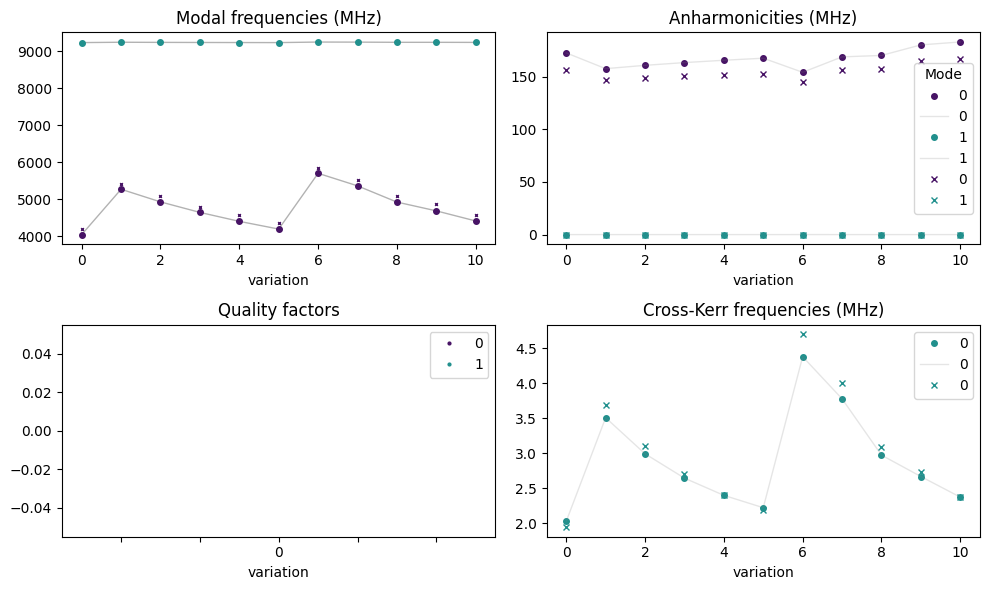

In [22]:
%matplotlib inline
# plot the figures in the notebook.

# This is the core object for working with post processing data from HFSS
# This iwll load the saved solutions from above
epra = epr.QuantumAnalysis(eprh.data_filename)

# Analyze
epra.analyze_all_variations(cos_trunc = 8, fock_trunc = 15)
epra.plot_hamiltonian_results();

### Interpreting the Hamiltonian results

The `plot_hamiltonian_results()` output and the printed tables give the following quantum quantities:

**Chi matrix ($\chi$):**
The $\chi$ matrix encodes all second-order quantum corrections from the junction nonlinearity. In the standard dispersive approximation it takes the form $\hat{H} \supset \sum_{m,n} \chi_{mn} \hat{a}_m^\dagger \hat{a}_m \hat{a}_n^\dagger \hat{a}_n$.

- **Diagonal elements $\chi_{mm}$** (labeled `anharmonicity` $\alpha_m$): The self-Kerr coefficient, which sets how much the frequency of mode $m$ shifts for each additional photon in that mode. For the transmon, $\alpha_q \approx -E_C/h$ (where $E_C = e^2 / (2C_\Sigma)$ is the charging energy). A transmon with $\alpha \approx 200\,\text{MHz}$ can be selectively addressed with $\sim 10\,\text{ns}$ pulses.

- **Off-diagonal elements $\chi_{mn}$ ($m \ne n$)**: The cross-Kerr (dispersive coupling) between modes $m$ and $n$. In a qubit-cavity system, $\chi_{qc}$ is the dispersive shift used for qubit readout: the cavity resonance shifts by $\chi_{qc}$ depending on whether the qubit is in $|0\rangle$ or $|1\rangle$.

**Dressed frequencies vs. bare frequencies:**
The bare frequencies $\omega_m$ are the HFSS eigenfrequencies of the linearized circuit. The dressed frequencies $\tilde{\omega}_m$ include the **Lamb shift** — a downward frequency renormalization due to the quantum zero-point fluctuations coupling each mode to the junction nonlinearity. This shift is $\tilde{\omega}_m = \omega_m + \chi_{mm}/2 + \ldots$ to leading order in perturbation theory.

The two columns labeled `O1 PT` and `ND` give the first-order perturbation theory and numerical diagonalization results respectively. For a typical transmon with small $\varphi_{zpf}$, these agree to within a few percent.

See Section III and Table I of [arXiv:2010.00620](https://arxiv.org/abs/2010.00620) for a systematic comparison of these methods against experiment.

## <div style="background:#BBFABB;line-height:2em;"> Swept variable analysis driven through pyEPR:<br> Sweep variable in HFSS, analyze microwaves, then analyze quantum<div>

Let us now run a more complete example, where we sweep the Josephson inductance $L_J$. This demonstrates the full power of the pyEPR workflow: by sweeping $L_J$ (which is equivalent to varying the Josephson energy $E_J = \Phi_0^2 / (4\pi^2 L_J)$), we can trace out how the qubit frequency, anharmonicity, and dispersive coupling all depend on the junction parameter.

This is exactly how one would characterize the design space during the development of a new qubit device.

**Classical microwave, distributed analysis**

Sweep variable in HFSS, run the eigenmode solver for each value.

In [23]:
import numpy as np

### Configure setup
### Set the maximum number of passes on the analysis and a few other
pinfo.setup.passes = 15
pinfo.setup.min_freq = '3.2GHz'
pinfo.setup.modes = 2
pinfo.setup.delta_f = 0.02
pinfo.setup.basis_order = epr.ansys.BASIS_ORDER['Mixed Order']


### What to sweep
# Define sweep variables to go over
swp_var = 'Lj_1' # name
# how to convert sweep param to string variable in nanoHeries.
to_swp_val = lambda x: f'{x}nH'

### Run Sweep
for swp_param in np.linspace(6, 12, 6):
    swp_val = to_swp_val(swp_param)
    epr.logger.info(f'Setting sweep variable {swp_var}={swp_val}')
    pinfo.design.set_variable(swp_var, swp_val)
    pinfo.setup.analyze()

INFO 12:48PM [<module>]: Setting sweep variable Lj_1=6.0nH


INFO 12:48PM [analyze]: Analyzing setup Setup1


INFO 12:48PM [<module>]: Setting sweep variable Lj_1=7.2nH


INFO 12:48PM [analyze]: Analyzing setup Setup1


INFO 12:48PM [<module>]: Setting sweep variable Lj_1=8.4nH


...

INFO 12:48PM [analyze]: Analyzing setup Setup1


INFO 12:48PM [<module>]: Setting sweep variable Lj_1=10.8nH


INFO 12:48PM [analyze]: Analyzing setup Setup1


INFO 12:48PM [<module>]: Setting sweep variable Lj_1=12.0nH


INFO 12:48PM [analyze]: Analyzing setup Setup1


**EPR microwave analysis**

Classical-to-quantum bridge: compute participation ratios for all sweep points.

INFO 12:48PM [__init__]: Design "1. single_transmon" info:


INFO 12:48PM [__init__]: 	# eigenmodes    2
	# variations    11


INFO 12:48PM [hfss_report_full_convergence]: Creating report for variation 0


INFO 12:48PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


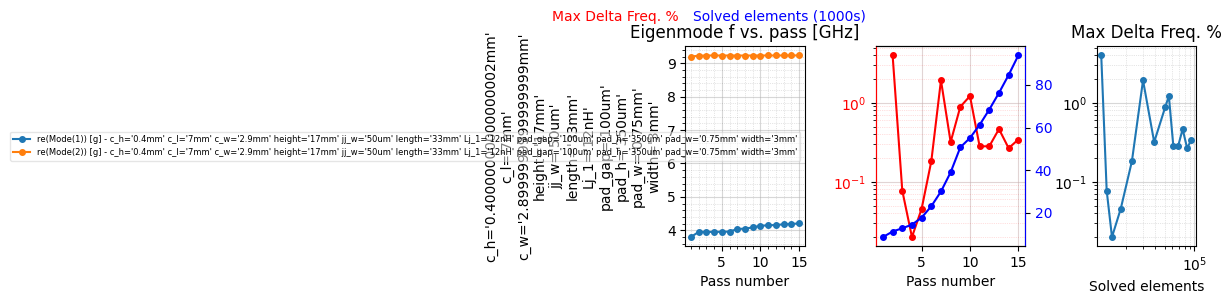

INFO 12:48PM [hfss_report_full_convergence]: Creating report for variation 1


INFO 12:48PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


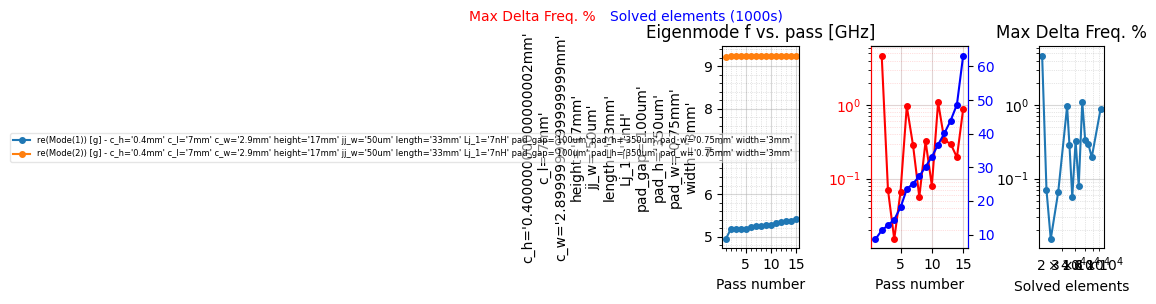

INFO 12:48PM [hfss_report_full_convergence]: Creating report for variation 2


INFO 12:48PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


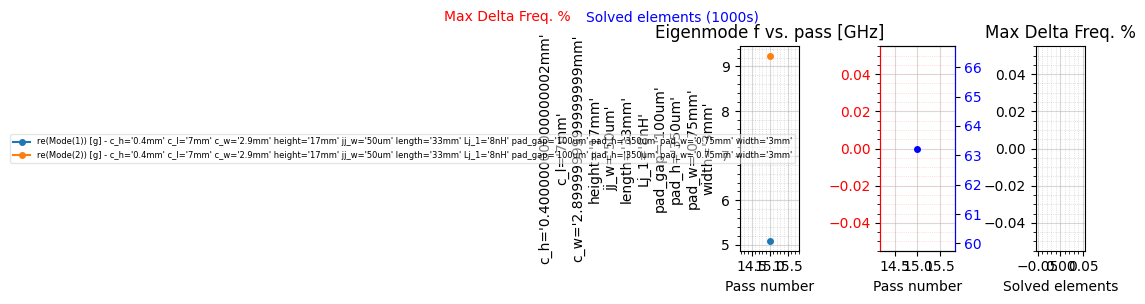

INFO 12:48PM [hfss_report_full_convergence]: Creating report for variation 3


INFO 12:48PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


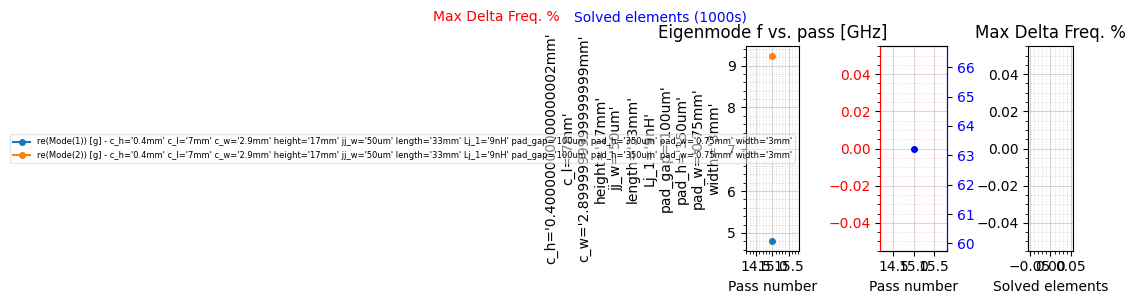

INFO 12:48PM [hfss_report_full_convergence]: Creating report for variation 4


INFO 12:48PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


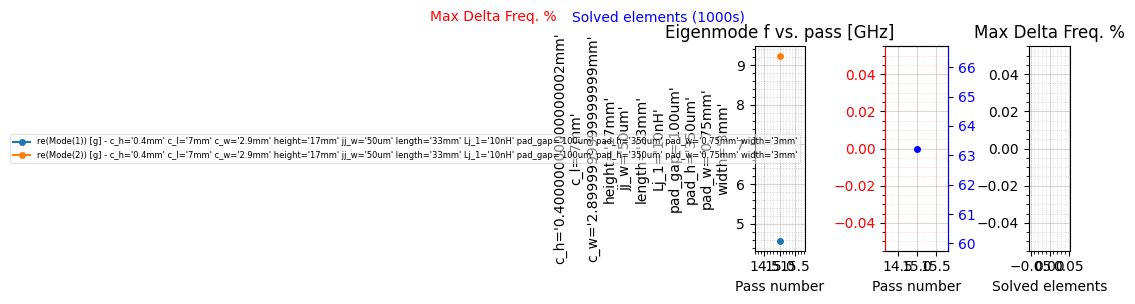

INFO 12:48PM [hfss_report_full_convergence]: Creating report for variation 5


INFO 12:48PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


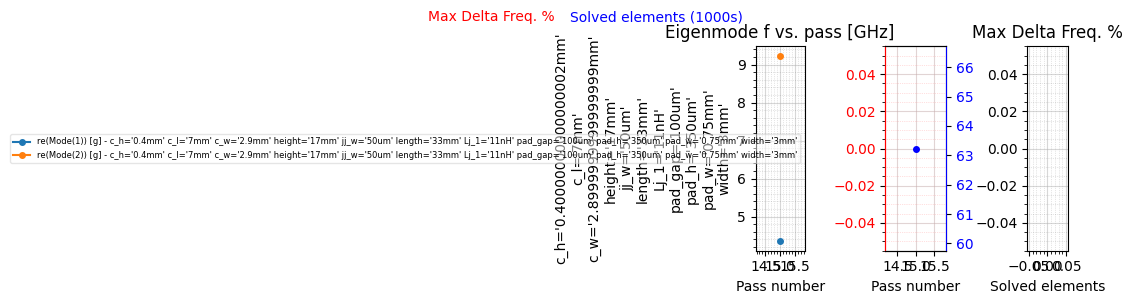

INFO 12:48PM [hfss_report_full_convergence]: Creating report for variation 6


INFO 12:48PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


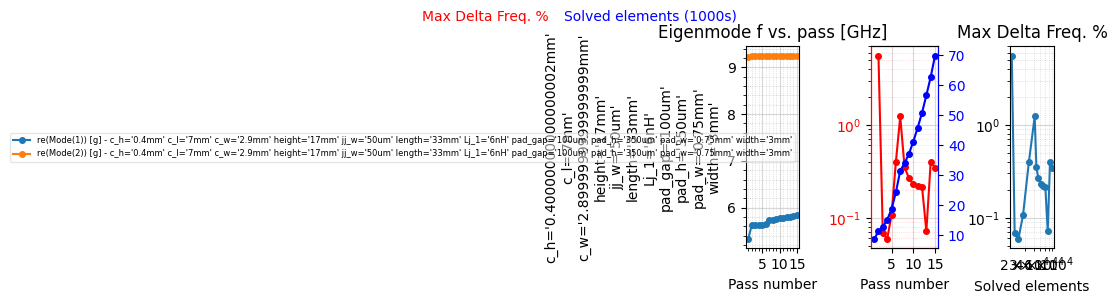

INFO 12:48PM [hfss_report_full_convergence]: Creating report for variation 7


INFO 12:48PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


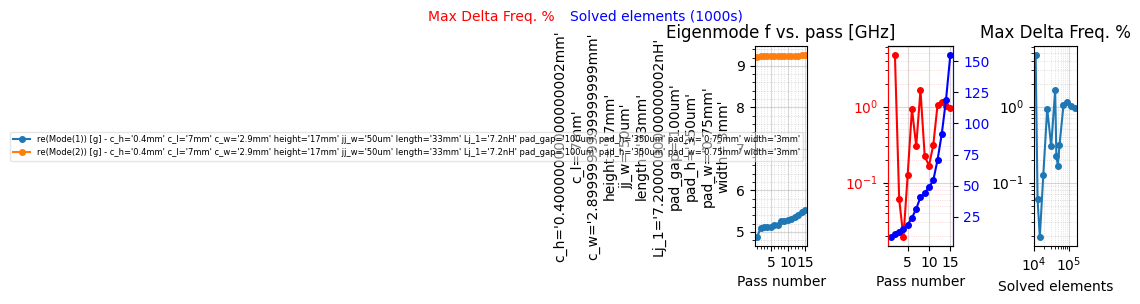

INFO 12:48PM [hfss_report_full_convergence]: Creating report for variation 8


INFO 12:48PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


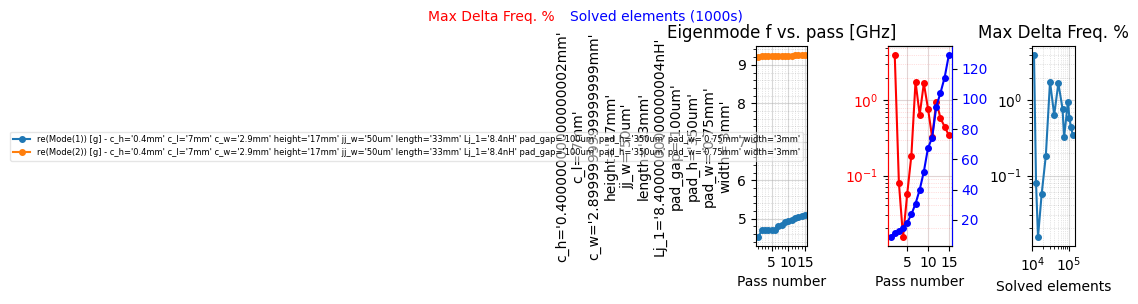

INFO 12:48PM [hfss_report_full_convergence]: Creating report for variation 9


INFO 12:48PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


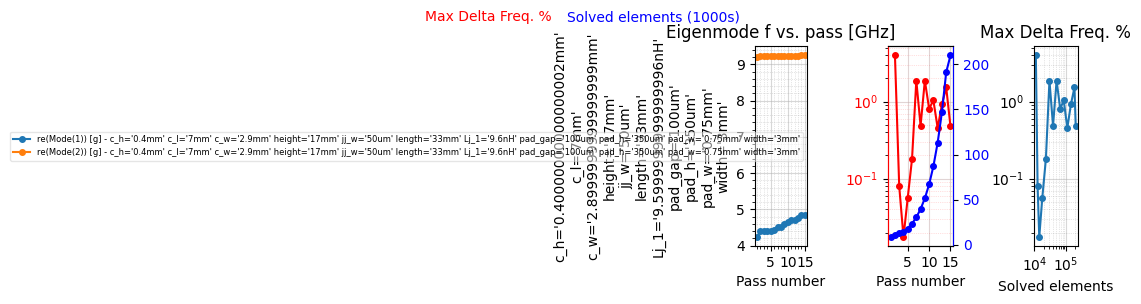

INFO 12:48PM [hfss_report_full_convergence]: Creating report for variation 10


INFO 12:48PM [hfss_report_f_convergence]: Saved convergences to C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\hfss_eig_f_convergence.csv


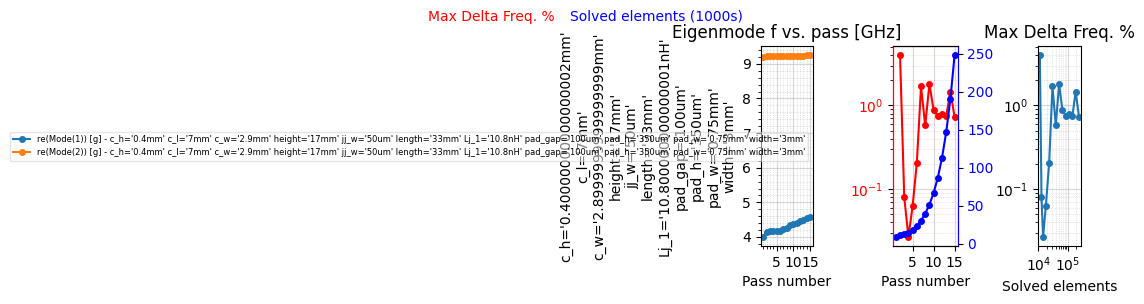

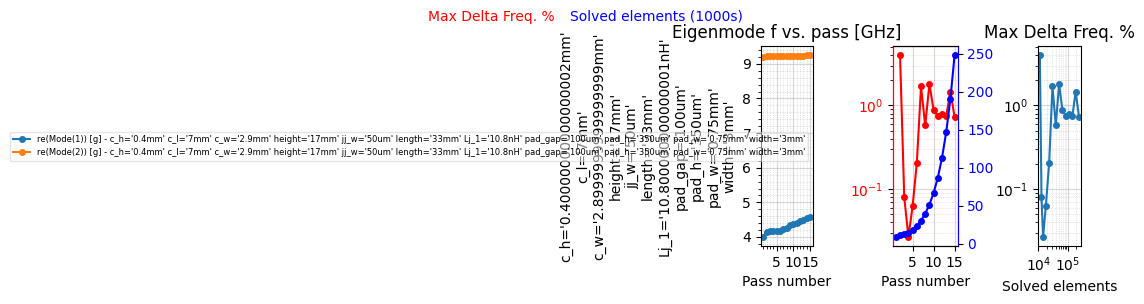

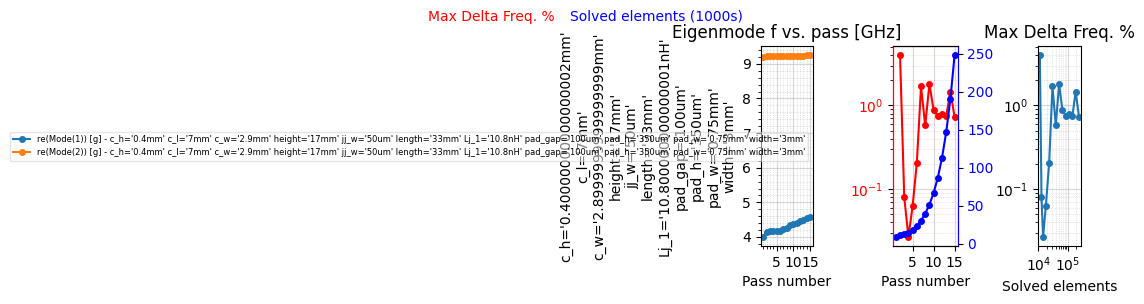

In [24]:
eprh = epr.DistributedAnalysis(pinfo) # epr hfss analysis
eprh.hfss_report_full_convergence()

In [25]:
# Do EPR analysis for all modes and all variations
eprh.do_EPR_analysis();

INFO 12:48PM [do_EPR_analysis]: Variation 0  [1/11]


INFO 12:48PM [do_EPR_analysis]: Mode 0 at 4.20 GHz   [1/2]


INFO 12:48PM [do_EPR_analysis]:     Calculating E_magnetic ...


INFO 12:48PM [do_EPR_analysis]:     Calculating E_electric ...


INFO 12:48PM [do_EPR_analysis]:      (E_E-E_H)/E_E=  98.2%   E_E=3.807e-22   E_H=6.757e-24


...

DEBUG 12:49PM [calc_p_junction]: Calculating participations for ('j1', {'Lj_variable': 'Lj_1', 'rect': 'rect_jj1', 'line': 'line_jj1', 'length': 9.999999999999999e-05})


DEBUG 12:49PM [calc_current_using_line_voltage]: 		Energy fraction (Lj over Lj&Cj)= 93.21%


INFO 12:49PM [calc_p_junction]: 	j1              0.00346618  (-)        0.000252487


INFO 12:49PM [calc_p_junction]: 		(U_tot_cap-U_tot_ind)/mean=0.01%


INFO 12:49PM [do_EPR_analysis]: ANALYSIS DONE. Data saved to: C:\data-pyEPR\pyEPR_tutorial1\1. single_transmon\2026-07-03 12-48-25.npz


**Quantum analysis**

Perform the Hamiltonian diagonalization and plot the results as a function of the swept parameter $L_J$.

In [26]:
# This is the core object for working with post processing data from HFSS
# This will load the saved solutions from above
epra = epr.QuantumAnalysis(eprh.data_filename)

INFO 12:49PM [print_info]: 	 Differences in variations:


variation,0,1,2,3,4,5,6,7,8,9,10
_Lj_1,12nH,7nH,8nH,9nH,10nH,11nH,6nH,7.2000000000000002nH,8.4000000000000004nH,9.5999999999999996nH,10.800000000000001nH


INFO 12:49PM [print_info]: 


In [27]:
# Analyze
epra.analyze_all_variations(cos_trunc = 8, fock_trunc = 15);

INFO 12:49PM [analyze_variation]: . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 


INFO 12:49PM [analyze_variation]: Variation 0


DEBUG 12:49PM [get_epr_base_matrices]: PJ=


DEBUG 12:49PM [get_epr_base_matrices]: [[0.98238277]
 [0.00277641]]


DEBUG 12:49PM [get_epr_base_matrices]: SJ=


...

INFO 12:49PM [print_result]: *** Chi matrix O1 PT (MHz) — diag: anharmonicity, off-diag: cross-Kerr
       166     2.37
      2.37  0.00847


INFO 12:49PM [print_result]: *** Chi matrix ND (MHz)
    183+0j  2.37+0j
   2.37+0j0.00773+0j


INFO 12:49PM [print_result]: *** Frequencies O1 PT (MHz)
0    4414.450938
1    9241.263749
dtype: float64


INFO 12:49PM [print_result]: *** Frequencies ND (MHz)
0    4407.725244+   0.000000j
1    9241.248397+   0.000000j
dtype: complex128


INFO 12:49PM [print_result]: *** Q_coupling
Empty DataFrame
Columns: []
Index: [0, 1]


C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)


C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: C

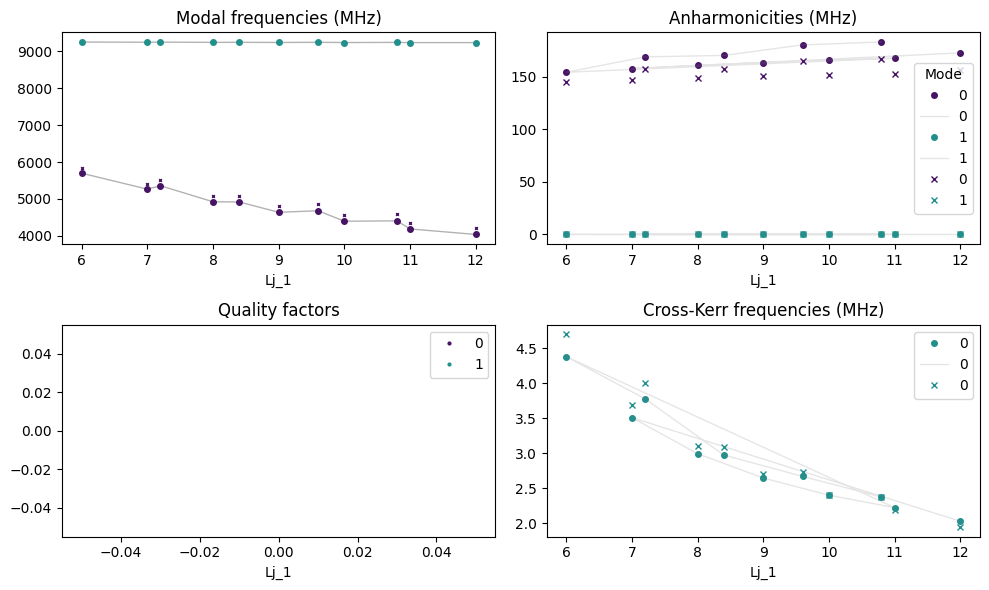

In [28]:
epra.plot_hamiltonian_results(swp_variable='Lj_1');

There is some jitter in the results since some of the runs were performed with only a few adaptive passes. In a production analysis one would ensure all variations have converged to the same $\Delta f$ threshold before proceeding.

The sweep makes several physically important trends visible:

- As $L_J$ increases, $E_J$ decreases, so the qubit frequency $\omega_q \propto \sqrt{E_J}$ decreases.
- The anharmonicity $\alpha \approx -E_C$ is relatively insensitive to $L_J$ in the transmon regime (since $E_C$ is set by the capacitor geometry, not the junction).
- The dispersive coupling $\chi_{qc}$ decreases as $L_J$ increases (equivalently, as $E_J / E_C$ increases and the qubit moves deeper into the transmon regime).

See Figure 3 of [arXiv:2010.00620](https://arxiv.org/abs/2010.00620) for an example of these trends in a real device.

C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Tim\anaconda3\envs\hfss\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Cas

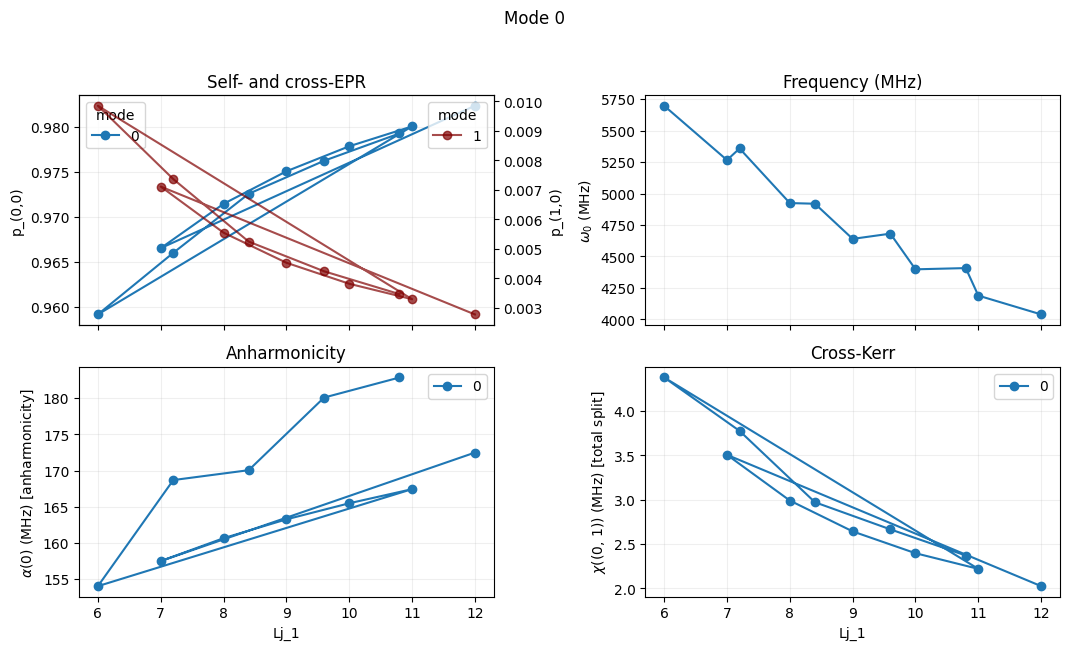

In [29]:
epra.quick_plot_mode(0,0,1,numeric=True,swp_variable='Lj_1')

In [30]:
epra.report_results(swp_variable='Lj_1', numeric=True)

#### Mode frequencies (MHz)

###### Numerical diagonalization

Lj_1,6.0,7.0,7.2,8.0,8.4,9.0,9.6,10.0,10.8,11.0,12.0
0,5698.13+ 0.00j,5266.30+ 0.00j,5358.72+ 0.00j,4924.58+ 0.00j,4919.34+ 0.00j,4639.85+ 0.00j,4681.47+ 0.00j,4397.88+ 0.00j,4407.73+ 0.00j,4188.96+ 0.00j,4039.34+ 0.00j
1,9250.68+ 0.00j,9245.38+ 0.00j,9248.54+ 0.00j,9241.78+ 0.00j,9243.54+ 0.00j,9239.24+ 0.00j,9243.45+ 0.00j,9237.35+ 0.00j,9241.25+ 0.00j,9235.89+ 0.00j,9235.99+ 0.00j


#### Kerr Non-linear coefficient table (MHz)

###### Numerical diagonalization

0                   1
Lj_1                                      
12.0 0  172.48+  0.00j  2.03e+00+0.00e+00j
     1    2.03+  0.00j  5.73e-03+0.00e+00j
7.0  0  157.50+  0.00j  3.51e+00+0.00e+00j
     1    3.51+  0.00j  2.05e-02+0.00e+00j
8.0  0  160.66+  0.00j  2.99e+00+0.00e+00j
     1    2.99+  0.00j  1.47e-02+0.00e+00j
9.0  0  163.26+  0.00j  2.64e+00+0.00e+00j
     1    2.64+  0.00j  1.09e-02+0.00e+00j
10.0 0  165.48+  0.00j  2.40e+00+0.00e+00j
     1    2.40+  0.00j  8.74e-03+0.00e+00j
11.0 0  167.43+  0.00j  2.22e+00+0.00e+00j
     1    2.22+  0.00j  7.26e-03+0.00e+00j
6.0  0  154.04+  0.00j  4.38e+00+0.00e+00j
     1    4.38+  0.00j  3.29e-02+0.00e+00j
7.2  0  168.68+  0.00j  3.78e+00+0.00e+00j
     1    3.78+  0.00j  2.23e-02+0.00e+00j
8.4  0  170.05+  0.00j  2.97e+00+0.00e+00j
     1    2.97+  0.00j  1.41e-02+0.00e+00j
9.6  0  180.07+  0.00j  2.67e+00+0.00e+00j
     1    2.67+  0.00j  1.01e-02+0.00e+00j
10.8 0  182.84+  0.00j  2.37e+00+0.00e+00j
     1    2.37+  0.00j  7.73e-03+0.00e+00j

# <div style="background:#BBFABB;line-height:2em;"> Addendum: <br> Snippets for ease <div>

An easy way to define many junctions is the following, using Python 3 f-strings for ease. This pattern is useful for multi-junction circuits such as flux qubits, SQUID arrays, or fluxonium qubits, where each junction must be registered individually but shares a common naming convention:

In [31]:
# Specify multiple junctions in HFSS model
n_junctions = 5
for i in range(1, 1+n_junctions):
    pinfo.junctions[f'j{i}'] = {'Lj_variable' : f'Lj{i}',
                                'rect'        : f'JJrect{i}',
                                'line'        : f'JJline{i}',
                                'length'      : epr.parse_units('100um')}

**NEXT:** Please see *Tutorial 2* to continue. It covers the calculation of dielectric energy-participation ratios, which are needed to estimate qubit lifetimes $T_1$ from dielectric loss tangents.